# T37 — Cenozoic planktonic foraminifera on reconstructed paleo-latitude

**Cenozoic deep-sea planktonic foraminifera community migration through 65 Ma of plate motion. Reconstructs DSDP/ODP/IODP drill sites to their sample ages with `gplately`, plots community structure against paleo-latitude instead of present-day latitude, and shows how the high-latitude assemblage expands equatorward through the Eocene–Oligocene cooling transition.**

## Why this notebook is different from the original draft

An earlier draft of T37 used the Holocene/LGM ForCenS database. At 20 ka (LGM) the global plate-reconstruction displacement is ~40 m — negligible against the spatial resolution of any community-distribution map. The "reconstruction" step was therefore window-dressing. This rewritten T37 anchors the same conceptual workflow (community structure on paleo-coordinates) to a dataset where the reconstruction does real work: Cenozoic foraminifera at deep-sea sites that have moved tens of degrees of latitude through the Cenozoic.

## What this notebook produces

(i) A reconstructed paleo-map of foraminifera occurrences at three representative Cenozoic ages (60, 35, 10 Ma) coloured by genus, showing how the polar-ice expansion squeezes tropical species toward the equator; (ii) a paleo-latitude histogram per epoch showing the contraction of the tropical band through the Cenozoic; (iii) the per-site "paleo-latitude trajectory" — each DSDP/ODP site's path through latitude space across its occupied age range.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Reconstruct a set of fixed drill-site coordinates to their per-occurrence sample ages with `gplately`.
- Distinguish present-day latitude (where you sample) from paleo-latitude (where the rock was deposited) — and explain why ignoring the distinction biases Cenozoic biogeography.
- Compute community-composition histograms vs paleo-latitude for binned epochs.
- Recognise the Cenozoic-cooling signal in foram communities: tropical assemblage contracts, polar assemblage expands equatorward.

## Prerequisites and runtime

- **Plate model**: Müller 2019.
- **Data**: `data/foraminifera_cenozoic/cenozoic_planktonic_forams.csv` (bundled, ~480 occurrences).
- **Python**: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`, `matplotlib`.
- **Runtime**: ~1 minute.

## Why Zahirovic 2022 in the paleomagnetic frame (anchor 701701)

Müller 2019 — and the Müller / Cao lineage in general — uses a *mantle / moving-hotspot* absolute reference frame. For paleo-latitude work (comparing reconstructed proxy sites against the latitudinal climate constraints those proxies record), the mantle frame is systematically wrong: it differs from the spin-axis frame by cumulative true polar wander, which can be many degrees in the Cenozoic.

For this notebook we use **Zahirovic 2022** with `anchor_plate_id = 701701` — the synthetic anchor in the Z22 rotation file that puts the model in the **paleomagnetic reference frame** (African plate motion expressed as paleomag-rotation chain, not as moving-hotspot chain). Reconstructed paleo-latitudes are then directly comparable to paleomagnetic and paleoclimate constraints. (Compare with T42, where Merdith 2021 — itself a paleomag-frame model — is used for the same reason at end-Permian times.)



## Data availability

This notebook reads the bundled `data/foraminifera_cenozoic/cenozoic_planktonic_forams.csv`. The shape mirrors PBDB (https://paleobiodb.org/) and Neptune Sandbox NSB exports: `occurrence_no, site, lon, lat, age_ma, genus, species, biome`. For full-dataset work:

- **PBDB (open)**: https://paleobiodb.org/data1.2/occs/list.csv?base_name=Globigerinoidea,Globorotaliidae&interval=Cenozoic&show=coords,age
- **Neptune Sandbox NSB**: https://www.nsb-mfn-berlin.de/ — DSDP/ODP/IODP-aligned, peer-reviewed taxonomy. Registration + terms-of-use apply.
- **CHRONOS Neptune mirror**: alternative access route.

For the tutorial the bundled subset is enough; for a publication-grade analysis, swap the loader to the PBDB CSV (or Neptune nc/zip) and reuse the rest of the notebook.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
FORAMS_CSV   = "data/foraminifera_cenozoic/cenozoic_planktonic_forams.csv"
MODEL_NAME   = "Zahirovic2022"
SNAPSHOT_TIMES_MA = (60.0, 35.0, 10.0)  # Paleocene, Eocene-Olig boundary, late Miocene
ANCHOR_PLATE_ID = 701701   # Zahirovic 2022 paleomag-frame anchor (African plate, paleomag rotations)
PALEOLAT_BINS = np.arange(-90, 95, 10)   # 10-deg bins
# ============================================================================


## 1. Load the foram occurrences

In [3]:
# Cell 2 — load
df = pd.read_csv(FORAMS_CSV, comment="#")
# Clean column whitespace
df.columns = [c.strip() for c in df.columns]
print(f"  {len(df)} occurrences  |  {df.site.nunique()} sites  |  {df.genus.nunique()} genera")
print(f"  age range: {df.age_ma.min():.1f} – {df.age_ma.max():.1f} Ma")
df.head()


  478 occurrences  |  16 sites  |  14 genera
  age range: 0.0 – 64.7 Ma


,occurrence_no,site,lon,lat,age_ma,genus,species,biome
0,1,DSDP-289,158.5,-1.0,1.77,Globigerinoides,ruber,tropical
1,2,IODP-U1338,-117.9,2.5,10.57,Globigerinoides,ruber,tropical
2,3,DSDP-167,-161.0,7.0,10.24,Globigerinoides,ruber,tropical
3,4,DSDP-167,-161.0,7.0,21.01,Globigerinoides,ruber,tropical
4,5,DSDP-289,158.5,-1.0,1.59,Globigerinoides,ruber,tropical


## 2. Reconstruct each occurrence to its sample age

In [4]:
# Cell 3 — per-occurrence paleo-positions
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

paleo_lons, paleo_lats = [], []
for _, row in df.iterrows():
    pt = gplately.Points(recon, [row["lon"]], [row["lat"]],
                         anchor_plate_id=ANCHOR_PLATE_ID)
    rlon, rlat = pt.reconstruct(float(row["age_ma"]),
                                anchor_plate_id=ANCHOR_PLATE_ID,
                                return_array=True)
    paleo_lons.append(float(rlon[0])); paleo_lats.append(float(rlat[0]))
df["paleo_lon"] = paleo_lons
df["paleo_lat"] = paleo_lats

# Quick sanity check: how much did the median site move?
shift = (df["paleo_lat"] - df["lat"]).abs().median()
print(f"\nMedian |Δlatitude| from reconstruction: {shift:.1f}°  (compare to ~0.0° for LGM)")



Median |Δlatitude| from reconstruction: 3.3°  (compare to ~0.0° for LGM)


## 3. Per-snapshot paleo-Earth map of forams coloured by genus

  60 Ma: 52 occurrences in ±5 Myr window


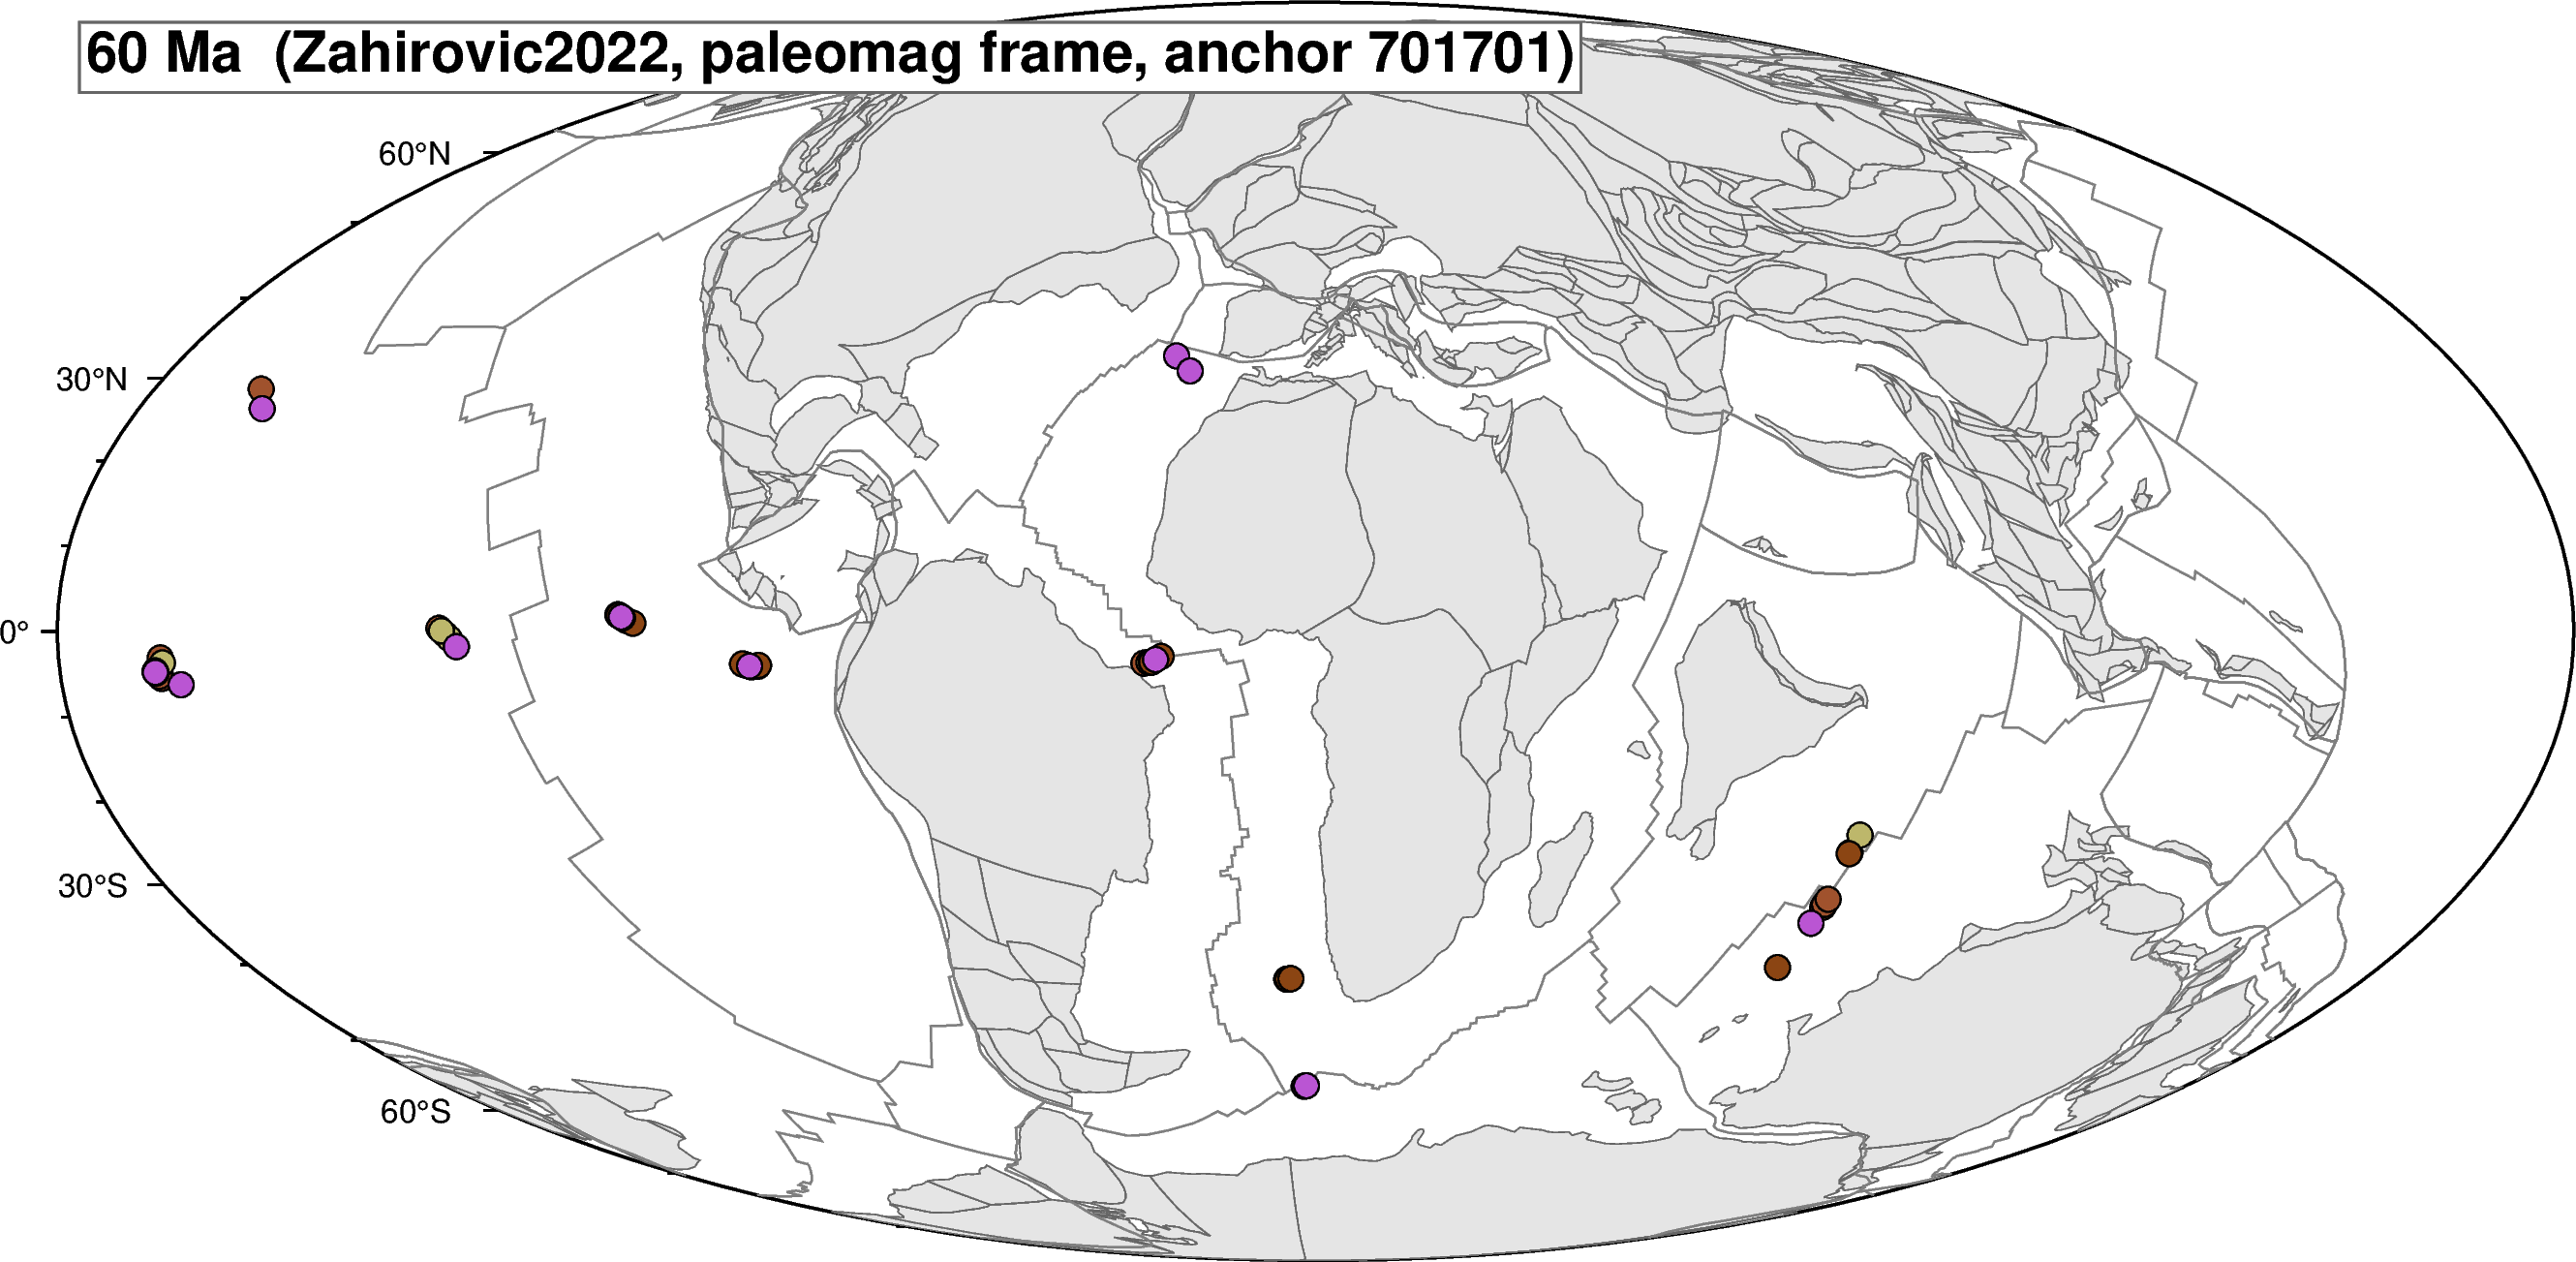

  35 Ma: 42 occurrences in ±5 Myr window


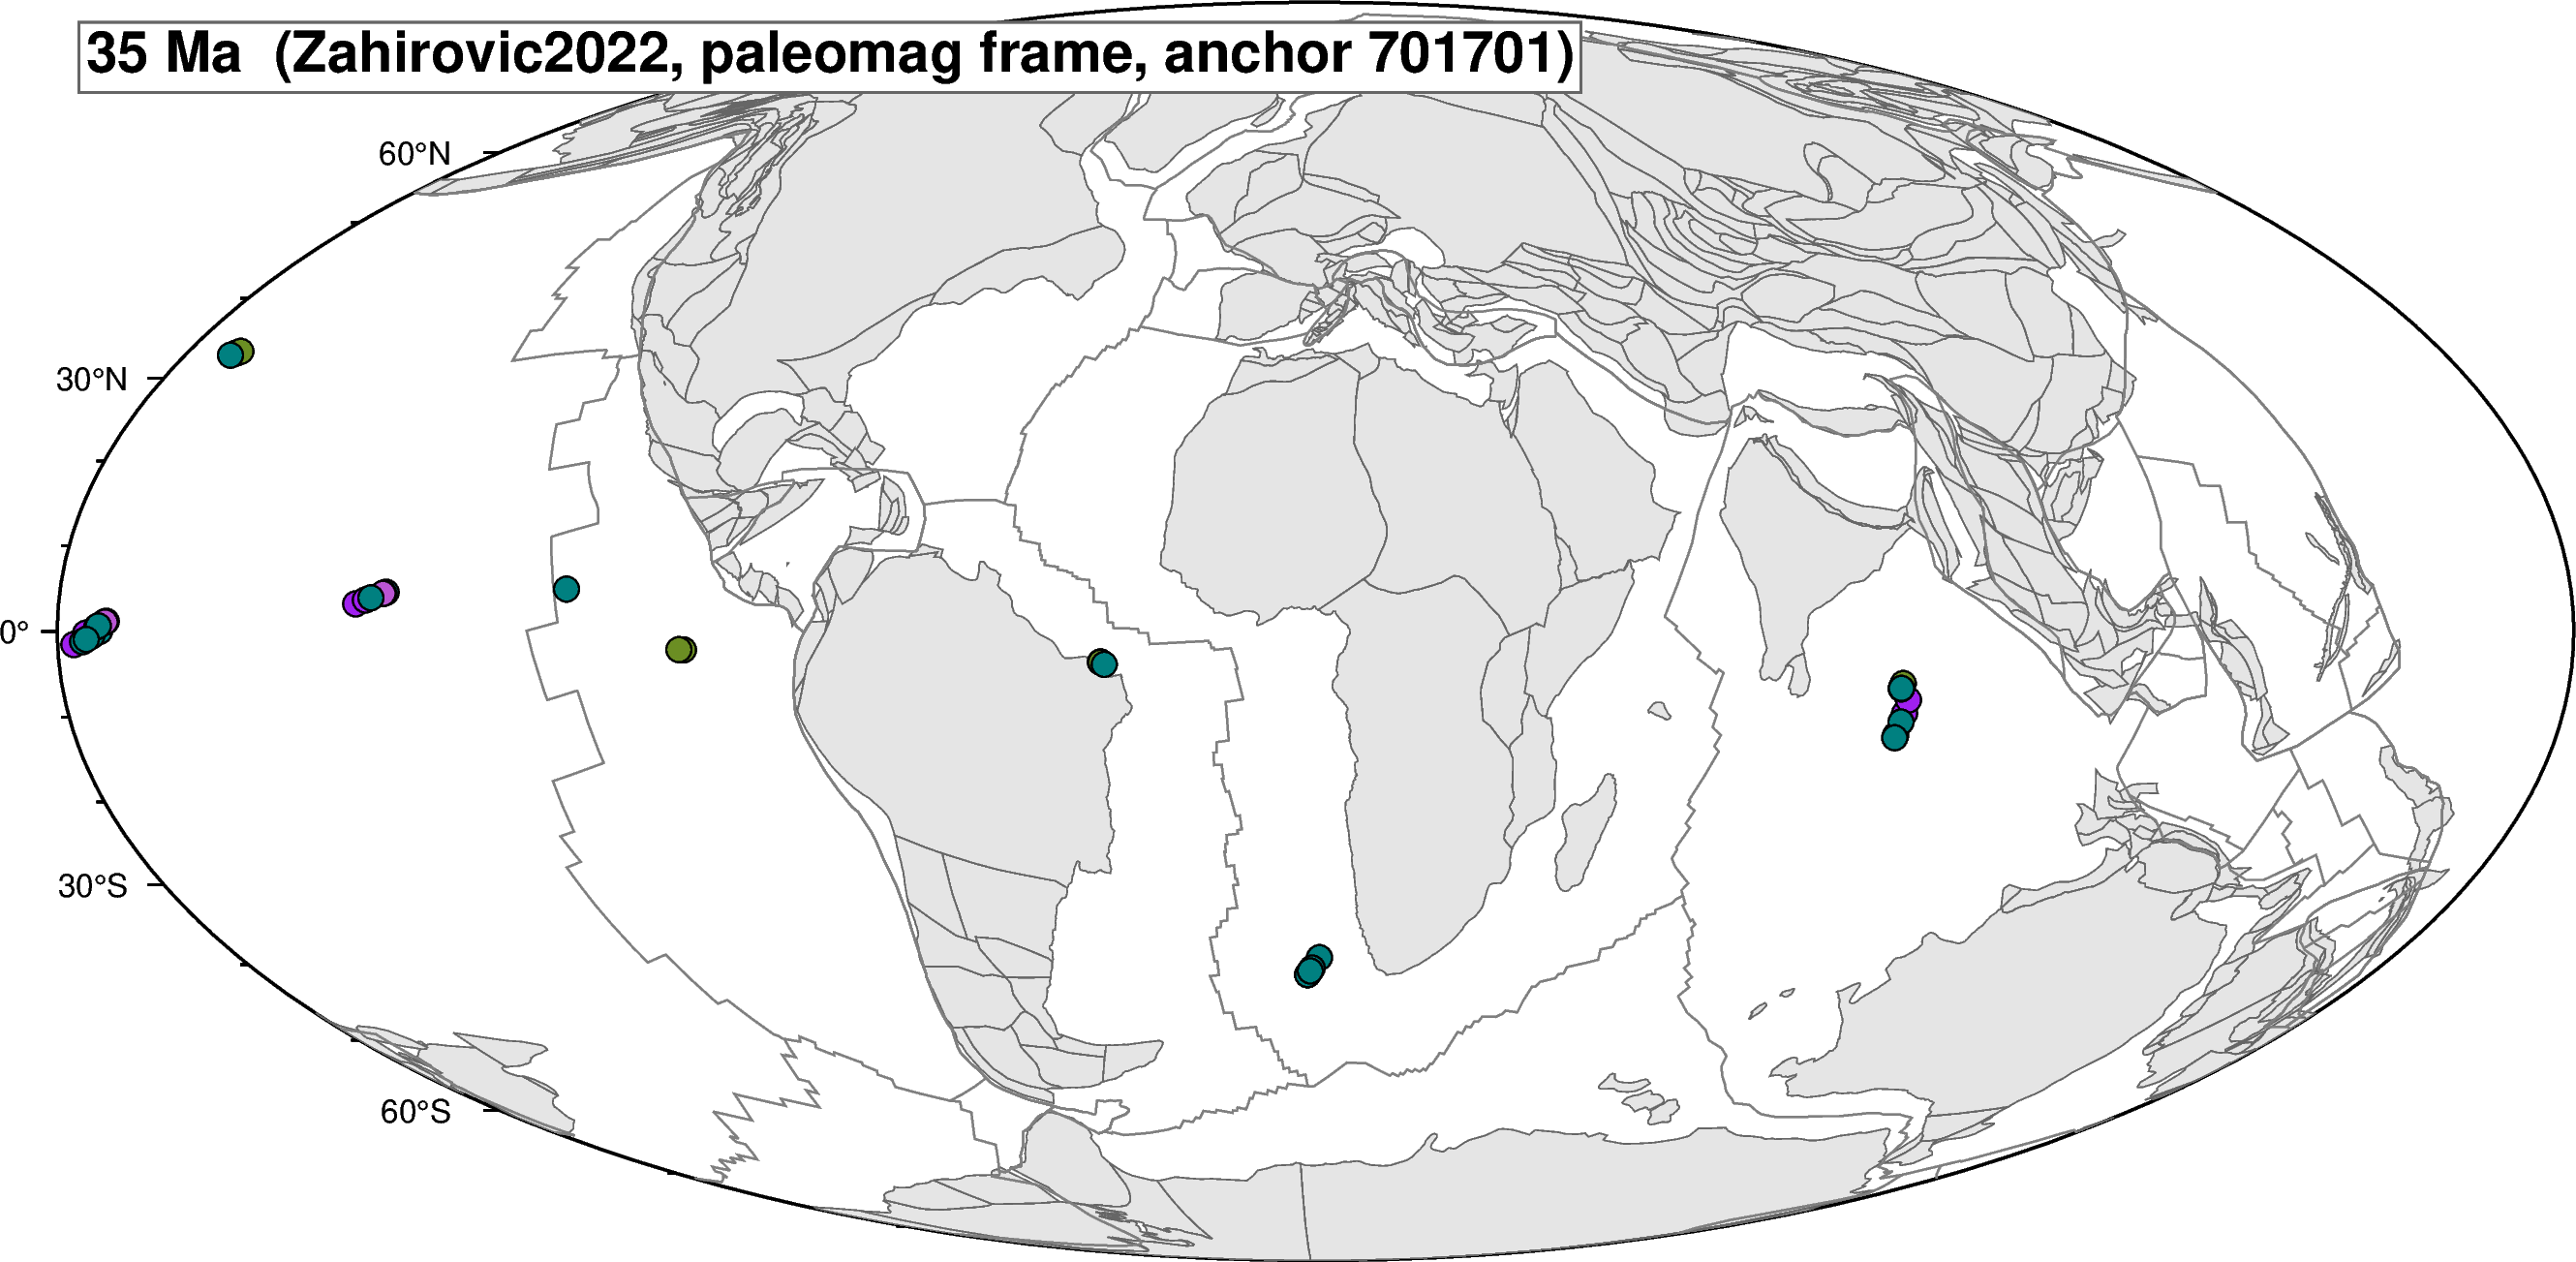

  10 Ma: 130 occurrences in ±5 Myr window


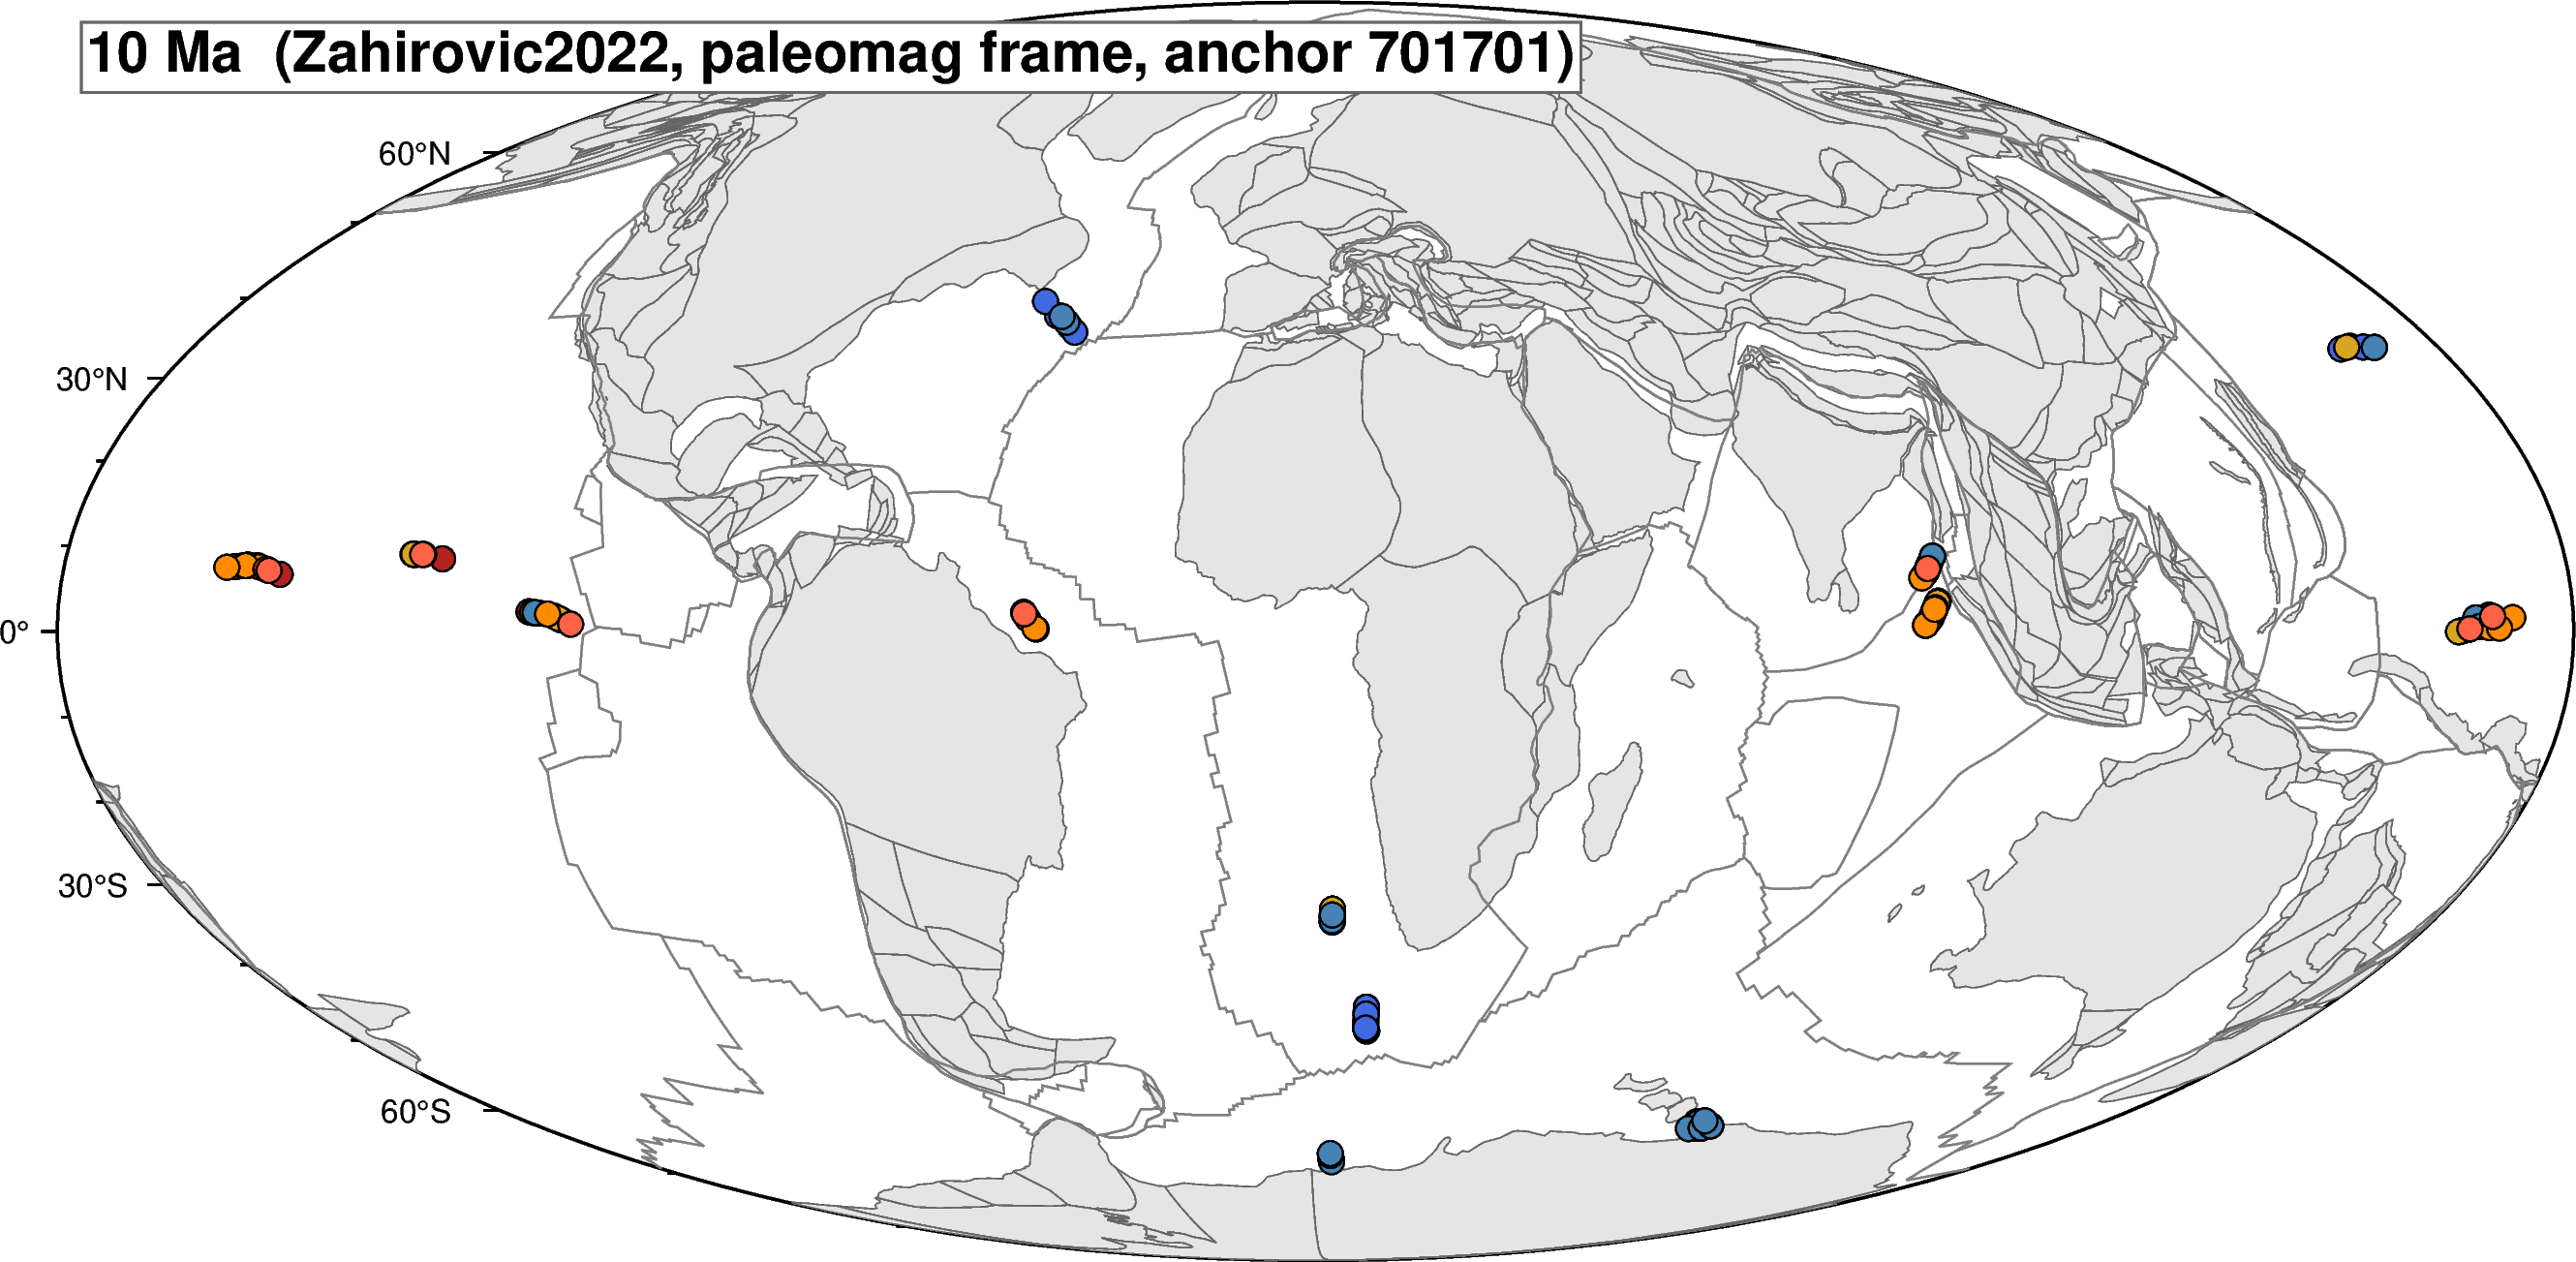

In [5]:
# Cell 4 — three snapshots
GENUS_COLOURS = {
    "Globigerinoides":   "firebrick",
    "Trilobatus":        "tomato",
    "Orbulina":          "darkorange",
    "Globorotalia":      "goldenrod",
    "Neogloboquadrina":  "steelblue",
    "Globigerina":       "royalblue",
    "Catapsydrax":       "purple",
    "Subbotina":         "mediumorchid",
    "Morozovella":       "saddlebrown",
    "Acarinina":         "sienna",
    "Hantkenina":        "olivedrab",
    "Globanomalina":     "darkkhaki",
    "Globigerinatheka":  "darkcyan",
    "Turborotalia":      "#008080",   # teal — GMT does not recognise the name, use hex
}

for t in SNAPSHOT_TIMES_MA:
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(t))
    engine = gplately.PygmtPlotEngine()

    window = df[(df["age_ma"] >= t - 5) & (df["age_ma"] <= t + 5)]
    print(f"  {t:.0f} Ma: {len(window)} occurrences in ±5 Myr window")

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray90", pen="0.3p,gray40")
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray50")

    # Group by genus, plot each
    for genus, gdf in window.groupby("genus"):
        col = GENUS_COLOURS.get(genus, "gray50")
        fig.plot(x=gdf["paleo_lon"], y=gdf["paleo_lat"],
                 style="c0.22c", fill=col, pen="0.4p,black")
    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME}, paleomag frame, anchor {ANCHOR_PLATE_ID})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))


## 4. Paleo-latitude histogram per epoch — tropical contraction signal

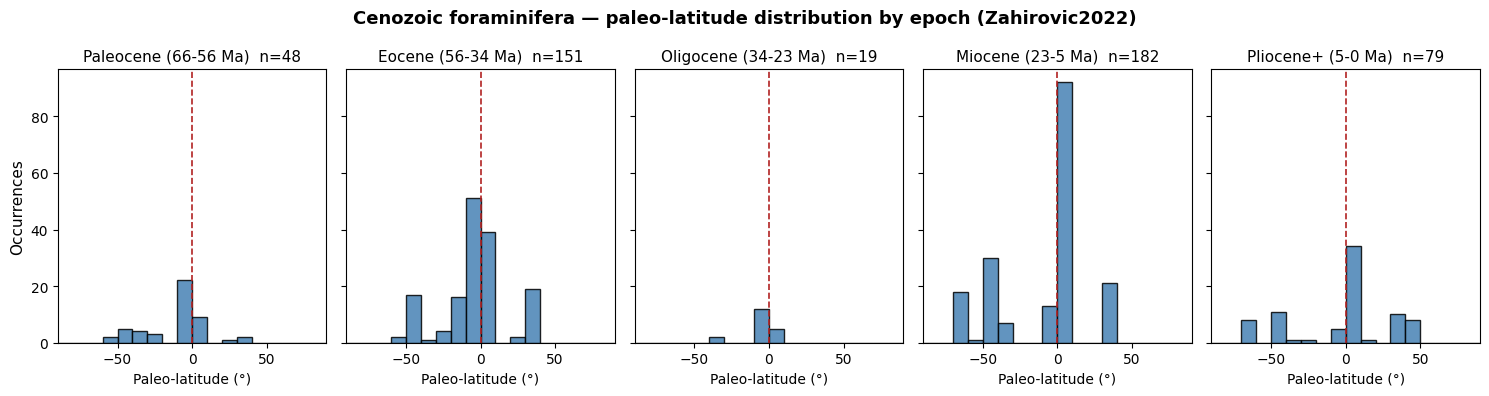

In [6]:
# Cell 5 — histograms
EPOCHS = [("Paleocene", 56, 66),
          ("Eocene",    34, 56),
          ("Oligocene", 23, 34),
          ("Miocene",    5, 23),
          ("Pliocene+",  0,  5)]

fig, axes = plt.subplots(1, len(EPOCHS), figsize=(15, 4), sharey=True)
for ax, (name, t0, t1) in zip(axes, EPOCHS):
    win = df[(df["age_ma"] >= t0) & (df["age_ma"] <= t1)]
    ax.hist(win["paleo_lat"], bins=PALEOLAT_BINS,
            color="steelblue", edgecolor="black", alpha=0.85)
    ax.axvline(0, color="firebrick", lw=1.2, ls="--")
    ax.set_xlim(-90, 90)
    ax.set_title(f"{name} ({t1}-{t0} Ma)  n={len(win)}", fontsize=11)
    ax.set_xlabel("Paleo-latitude (°)", fontsize=10)
axes[0].set_ylabel("Occurrences", fontsize=11)
plt.suptitle(f"Cenozoic foraminifera — paleo-latitude distribution by epoch ({MODEL_NAME})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Per-site paleo-latitude trajectories

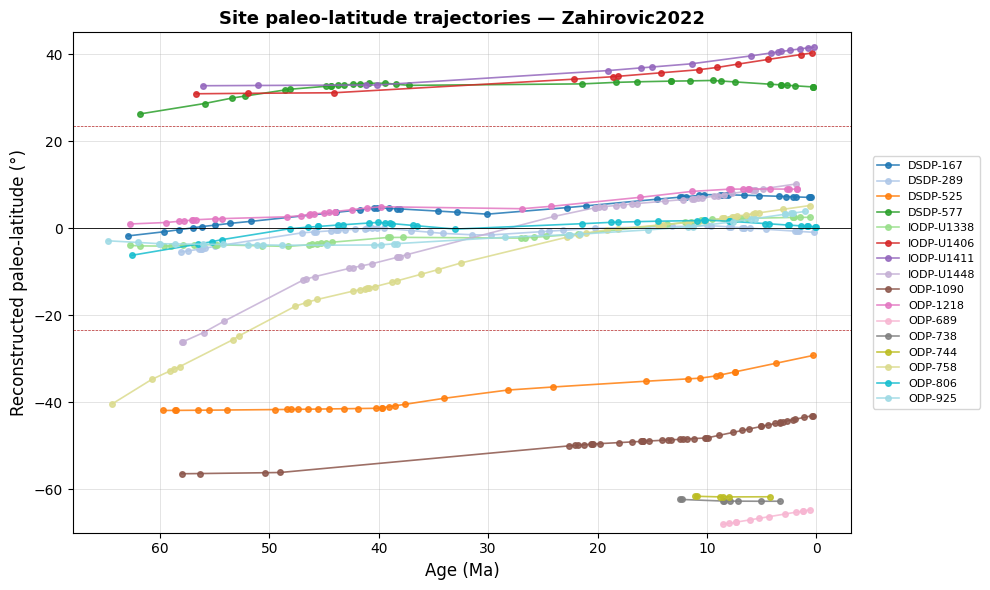

In [7]:
# Cell 6 — site trajectories
import matplotlib.cm as cmm

fig, ax = plt.subplots(figsize=(10, 6))
sites = sorted(df.site.unique())
cmap = plt.get_cmap("tab20", len(sites))
for i, s in enumerate(sites):
    sdf = df[df.site == s].sort_values("age_ma")
    ax.plot(sdf["age_ma"], sdf["paleo_lat"], "o-",
            color=cmap(i), lw=1.2, ms=4, label=s, alpha=0.85)

ax.invert_xaxis()
ax.axhline(0,   color="black", lw=0.6)
ax.axhline(23.5,color="firebrick", lw=0.5, ls="--")
ax.axhline(-23.5,color="firebrick",lw=0.5, ls="--")
ax.set_xlabel("Age (Ma)", fontsize=12)
ax.set_ylabel("Reconstructed paleo-latitude (°)", fontsize=12)
ax.set_ylim(-70, 45)
ax.set_title(f"Site paleo-latitude trajectories — {MODEL_NAME}", fontsize=13, fontweight="bold")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)
ax.grid(True, lw=0.4, alpha=0.6)
plt.tight_layout(); plt.show()


## Extend this

- **Real PBDB pull.** Replace the bundled subset by hitting the PBDB API at notebook runtime: `https://paleobiodb.org/data1.2/occs/list.csv?base_name=Globigerinoidea,Globorotaliidae&interval=Cenozoic&show=coords,age`. The rest of the notebook is unchanged.
- **Neptune Sandbox NSB.** Same workflow with Neptune's peer-reviewed taxonomy and stage-level age control. Register at https://www.nsb-mfn-berlin.de/ and download the CSV export.
- **Add SST.** Cross-reference with T41 (bayfox (https://github.com/brews/bayfox) δ¹⁸O→SST) — at each occurrence's reconstructed paleo-position, sample the contemporaneous reconstructed SST and bin community composition by paleo-SST instead of paleo-latitude.
- **Counter-point: the Holocene/LGM no-op.** Restrict the loader to age ≤ 0.02 Ma and re-run. The reconstruction step contributes nothing — exactly the original-T37 critique.

## References

- Lazarus, D. (1994). The Neptune project — a marine micropaleontology database. *Mathematical Geology* 26, 817-832.
- Lazarus, D. et al. (1995). NEPTUNE: a marine micropaleontology database. *Math. Geosciences* 27, 481-509.
- Müller, R.D. et al. (2019). A global plate model including lithospheric deformation along major rifts and orogens since the Triassic. *Tectonics* 38, 1884-1907.
- Cramer, B.S. et al. (2009). Ocean overturning since the Late Cretaceous. *Paleoceanography* 24, PA4216.  *(Cenozoic cooling reference.)*
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3-10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
